mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8221000000238419 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, Scikit-learn
Channels: emscripten-forge, conda-forge

Solving en

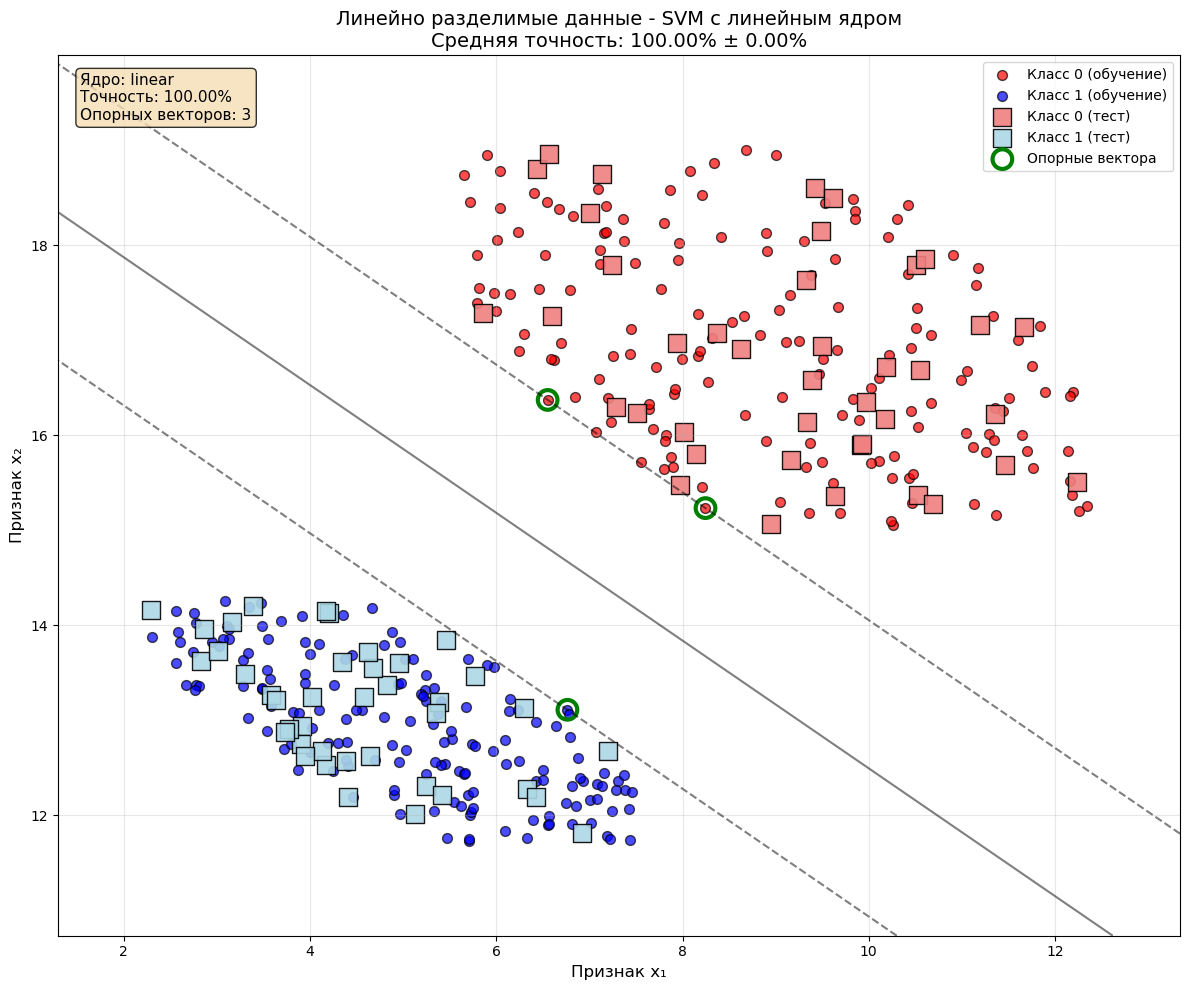

ЧАСТЬ 2: ЛИНЕЙНО НЕРАЗДЕЛИМЫЕ ДАННЫЕ (task217.csv)

Загрузка файла: task217.csv
✓ Файл успешно загружен
  Размер данных: (400, 3)
  Столбцы: ['x1', 'x2', 'target']
  Классы: [0 1]
  Класс 0: 200 объектов
  Класс 1: 200 объектов

АНАЛИЗ ЛИНЕЙНО НЕРАЗДЕЛИМЫХ ДАННЫХ (RBF ЯДРО)

1. Статистика признаков:
   x1: от 2.19 до 9.68, среднее=5.36
   x2: от 6.79 до 19.04, среднее=13.00

2. Проведение 10 экспериментов (ядро: rbf):
----------------------------------------
   Эксперимент  1: точность =  98.75% | Опорных векторов: 42
   Эксперимент  2: точность =  97.50% | Опорных векторов: 41
   Эксперимент  3: точность =  98.75% | Опорных векторов: 43
   Эксперимент  4: точность =  95.00% | Опорных векторов: 41
   Эксперимент  5: точность =  97.50% | Опорных векторов: 42
   Эксперимент  6: точность = 100.00% | Опорных векторов: 41
   Эксперимент  7: точность = 100.00% | Опорных векторов: 41
   Эксперимент  8: точность =  96.25% | Опорных векторов: 38
   Эксперимент  9: точность =  98.75% | Опорных в

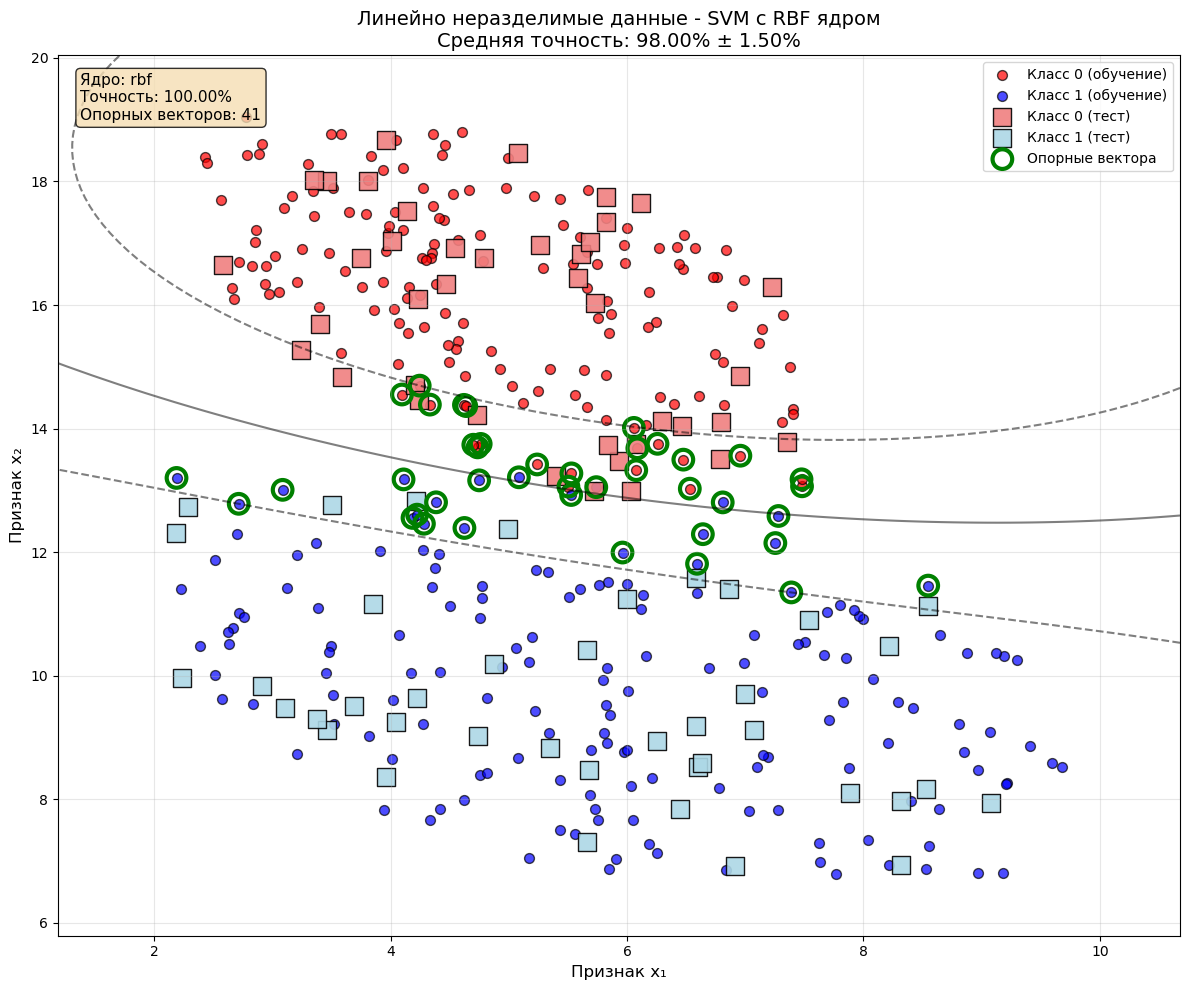

СРАВНЕНИЕ: ЛИНЕЙНОЕ ЯДРО НА НЕРАЗДЕЛИМЫХ ДАННЫХ

СРАВНЕНИЕ (ЛИНЕЙНОЕ ЯДРО)

1. Статистика признаков:
   x1: от 2.19 до 9.68, среднее=5.36
   x2: от 6.79 до 19.04, среднее=13.00

2. Проведение 10 экспериментов (ядро: linear):
----------------------------------------
   Эксперимент  1: точность =  98.75% | Опорных векторов: 16
   Эксперимент  2: точность =  98.75% | Опорных векторов: 15
   Эксперимент  3: точность =  98.75% | Опорных векторов: 15
   Эксперимент  4: точность =  95.00% | Опорных векторов: 13
   Эксперимент  5: точность =  97.50% | Опорных векторов: 15
   Эксперимент  6: точность =  98.75% | Опорных векторов: 15
   Эксперимент  7: точность = 100.00% | Опорных векторов: 16
   Эксперимент  8: точность =  96.25% | Опорных векторов: 15
   Эксперимент  9: точность =  98.75% | Опорных векторов: 15
   Эксперимент 10: точность =  97.50% | Опорных векторов: 15
3. РЕЗУЛЬТАТЫ СЕРИИ ЭКСПЕРИМЕНТОВ:
   Средняя точность: 98.00%
   Стандартное отклонение: 1.39%
   Минимальная точность: 95.

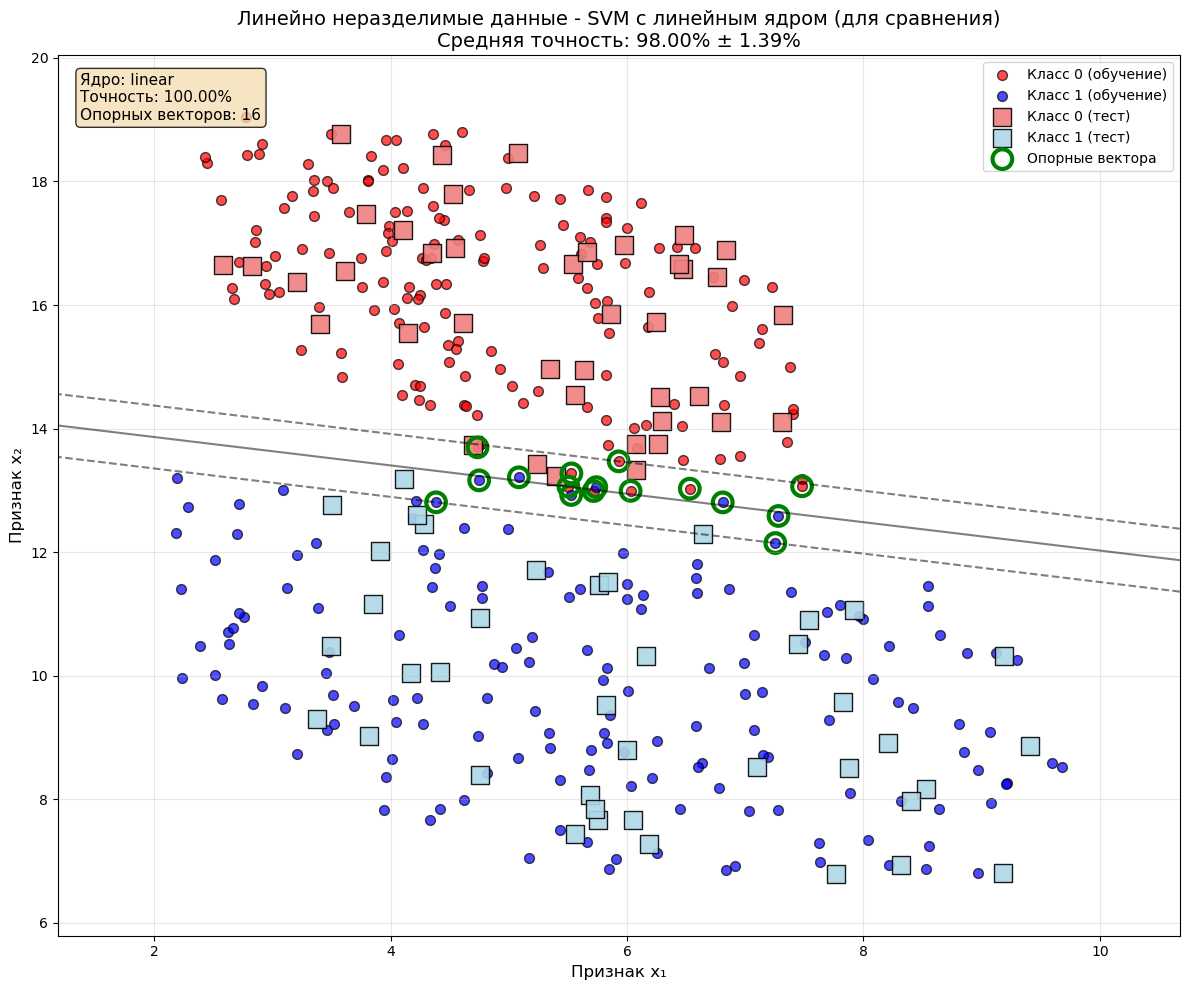

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
| Тип данных                | Ядро         | Ср.точность  | СТО      | Мин      | Макс     |
| Линейно разделимые        | linear       |     100.00% |   0.00% | 100.00% | 100.00% |
| Линейно неразделимые      | rbf          |      98.00% |   1.50% |  95.00% | 100.00% |
| Линейно неразделимые      | linear       |      98.00% |   1.39% |  95.00% | 100.00% |
РАБОТА ЗАВЕРШЕНА УСПЕШНО
Созданные графики:
  - svm_task117_result.png
  - svm_task217_rbf_result.png
  - svm_task217_linear_comparison.png


In [1]:
!mamba install pandas
!mamba install Scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("ПРАКТИЧЕСКАЯ РАБОТА №4: МЕТОД ОПОРНЫХ ВЕКТОРОВ (SVM)")
print("Вариант 17")

def load_data(filename):
    print(f"\nЗагрузка файла: {filename}")
    try:
        # Читаем файл с учетом заголовков
        df = pd.read_csv(filename)
        print(f"✓ Файл успешно загружен")
        print(f"  Размер данных: {df.shape}")
        print(f"  Столбцы: {list(df.columns)}")
        
        # Извлекаем признаки и целевую переменную
        X = df[['x1', 'x2']].values
        y = df['target'].values
        
        # Проверяем уникальные значения целевой переменной
        unique_classes = np.unique(y)
        print(f"  Классы: {unique_classes}")
        print(f"  Класс 0: {np.sum(y==0)} объектов")
        print(f"  Класс 1: {np.sum(y==1)} объектов")
        
        return X, y
    except Exception as e:
        print(f"✗ Ошибка при загрузке: {e}")
        return None, None


def analyze_svm_data(X, y, title, kernel_type='linear'):

    print(f"\n{title}")

    if X is None or y is None:
        print("✗ Нет данных для анализа")
        return None, None, None, None
    
    # Статистика по данным
    print(f"\n1. Статистика признаков:")
    print(f"   x1: от {X[:,0].min():.2f} до {X[:,0].max():.2f}, среднее={X[:,0].mean():.2f}")
    print(f"   x2: от {X[:,1].min():.2f} до {X[:,1].max():.2f}, среднее={X[:,1].mean():.2f}")
    
    # Серия из 10 экспериментов
    print(f"\n2. Проведение 10 экспериментов (ядро: {kernel_type}):")
    print("-" * 40)
    
    accuracies = []
    models = []
    
    for i in range(10):
        # Разделение данных (80% обучающая, 20% тестовая)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=i, stratify=y
        )
        
        # Создание и обучение модели SVM
        if kernel_type == 'rbf':
            model = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=i)
        else:
            model = svm.SVC(kernel='linear', C=1.0, random_state=i)
        
        model.fit(X_train, y_train)
        
        # Предсказание и оценка точности
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)
        models.append(model)
        
        print(f"   Эксперимент {i+1:2d}: точность = {accuracy*100:6.2f}% | "
              f"Опорных векторов: {len(model.support_vectors_)}")
    
    # Статистика по экспериментам
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    
    print("3. РЕЗУЛЬТАТЫ СЕРИИ ЭКСПЕРИМЕНТОВ:")
    print(f"   Средняя точность: {mean_acc*100:.2f}%")
    print(f"   Стандартное отклонение: {std_acc*100:.2f}%")
    print(f"   Минимальная точность: {np.min(accuracies)*100:.2f}%")
    print(f"   Максимальная точность: {np.max(accuracies)*100:.2f}%")
    
    # Выбираем модель с лучшей точностью для визуализации
    best_idx = np.argmax(accuracies)
    best_model = models[best_idx]
    
    # Получаем разбиение для лучшей модели
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=best_idx, stratify=y
    )
    
    print(f"\n4. Лучший результат (эксперимент {best_idx+1}):")
    print(f"   Точность: {accuracies[best_idx]*100:.2f}%")
    print(f"   Опорных векторов: {len(best_model.support_vectors_)}")
    
    return best_model, (X_train, X_test, y_train, y_test), accuracies, (mean_acc, std_acc)

def plot_svm_results(model, data_tuple, X_full, y_full, title, filename, kernel_type):

    X_train, X_test, y_train, y_test = data_tuple
    
    plt.figure(figsize=(12, 10))
    
    # Определяем границы графика
    x_min = min(X_full[:, 0].min(), X_test[:, 0].min()) - 1
    x_max = max(X_full[:, 0].max(), X_test[:, 0].max()) + 1
    y_min = min(X_full[:, 1].min(), X_test[:, 1].min()) - 1
    y_max = max(X_full[:, 1].max(), X_test[:, 1].max()) + 1
    
    # Создаем сетку для отображения разделяющей гиперплоскости
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Получаем значения решающей функции для точек сетки
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Отображаем разделяющую гиперплоскость и зазоры
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], 
                alpha=0.5, linestyles=['--', '-', '--'])
    
    # Отображаем точки обучающей выборки
    plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
                c='red', s=50, label='Класс 0 (обучение)', alpha=0.7, edgecolors='black')
    plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
                c='blue', s=50, label='Класс 1 (обучение)', alpha=0.7, edgecolors='black')
    
    # Отображаем точки тестовой выборки
    plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
                c='lightcoral', s=150, label='Класс 0 (тест)', alpha=0.9, 
                edgecolors='black', marker='s')
    plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
                c='lightblue', s=150, label='Класс 1 (тест)', alpha=0.9, 
                edgecolors='black', marker='s')
    
    # Выделяем опорные вектора
    support_vectors = model.support_vectors_
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
                s=200, facecolors='none', edgecolors='green', 
                linewidths=3, label='Опорные вектора')
    
    plt.xlabel('Признак x₁', fontsize=12)
    plt.ylabel('Признак x₂', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Добавляем информацию о модели
    accuracy = model.score(X_test, y_test)
    textstr = f'Ядро: {kernel_type}\nТочность: {accuracy*100:.2f}%\nОпорных векторов: {len(support_vectors)}'
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"   ✓ График сохранен: {filename}")
    plt.show()

# Словарь для хранения результатов
results = {}


print("ЧАСТЬ 1: ЛИНЕЙНО РАЗДЕЛИМЫЕ ДАННЫЕ (task117.csv)")

# Загружаем данные
X1, y1 = load_data('task117.csv')

if X1 is not None:
    # Анализ с линейным ядром
    model1, split1, accs1, stats1 = analyze_svm_data(
        X1, y1, "АНАЛИЗ ЛИНЕЙНО РАЗДЕЛИМЫХ ДАННЫХ", 'linear'
    )
    
    if model1 is not None:
        results['linear'] = {
            'model': model1,
            'split': split1,
            'X_full': X1,
            'y_full': y1,
            'accuracies': accs1,
            'mean': stats1[0],
            'std': stats1[1],
            'kernel': 'linear',
            'title': 'Линейно разделимые данные (task117.csv)'
        }
        
        # Визуализация
        plot_svm_results(
            model1, split1, X1, y1,
            f"Линейно разделимые данные - SVM с линейным ядром\n"
            f"Средняя точность: {stats1[0]*100:.2f}% ± {stats1[1]*100:.2f}%",
            'svm_task117_result.png',
            'linear'
        )

print("ЧАСТЬ 2: ЛИНЕЙНО НЕРАЗДЕЛИМЫЕ ДАННЫЕ (task217.csv)")

# Загружаем данные
X2, y2 = load_data('task217.csv')

if X2 is not None:
    # Анализ с RBF ядром
    model2, split2, accs2, stats2 = analyze_svm_data(
        X2, y2, "АНАЛИЗ ЛИНЕЙНО НЕРАЗДЕЛИМЫХ ДАННЫХ (RBF ЯДРО)", 'rbf'
    )
    
    if model2 is not None:
        results['rbf'] = {
            'model': model2,
            'split': split2,
            'X_full': X2,
            'y_full': y2,
            'accuracies': accs2,
            'mean': stats2[0],
            'std': stats2[1],
            'kernel': 'rbf',
            'title': 'Линейно неразделимые данные (task217.csv)'
        }
        
        # Визуализация
        plot_svm_results(
            model2, split2, X2, y2,
            f"Линейно неразделимые данные - SVM с RBF ядром\n"
            f"Средняя точность: {stats2[0]*100:.2f}% ± {stats2[1]*100:.2f}%",
            'svm_task217_rbf_result.png',
            'rbf'
        )
    
    print("СРАВНЕНИЕ: ЛИНЕЙНОЕ ЯДРО НА НЕРАЗДЕЛИМЫХ ДАННЫХ")
    
    model2_linear, split2_linear, accs2_linear, stats2_linear = analyze_svm_data(
        X2, y2, "СРАВНЕНИЕ (ЛИНЕЙНОЕ ЯДРО)", 'linear'
    )
    
    if model2_linear is not None:
        results['linear_on_nonlinear'] = {
            'model': model2_linear,
            'accuracies': accs2_linear,
            'mean': stats2_linear[0],
            'std': stats2_linear[1],
            'kernel': 'linear'
        }
        
        # Визуализация для сравнения
        plot_svm_results(
            model2_linear, split2_linear, X2, y2,
            f"Линейно неразделимые данные - SVM с линейным ядром (для сравнения)\n"
            f"Средняя точность: {stats2_linear[0]*100:.2f}% ± {stats2_linear[1]*100:.2f}%",
            'svm_task217_linear_comparison.png',
            'linear'
        )

print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")

print(f"| {'Тип данных':<25} | {'Ядро':<12} | {'Ср.точность':<12} | {'СТО':<8} | {'Мин':<8} | {'Макс':<8} |")

if 'linear' in results:
    r = results['linear']
    acc = r['accuracies']
    print(f"| {'Линейно разделимые':<25} | {'linear':<12} | {r['mean']*100:>10.2f}% | {r['std']*100:>6.2f}% | "
          f"{np.min(acc)*100:>6.2f}% | {np.max(acc)*100:>6.2f}% |")

if 'rbf' in results:
    r = results['rbf']
    acc = r['accuracies']
    print(f"| {'Линейно неразделимые':<25} | {'rbf':<12} | {r['mean']*100:>10.2f}% | {r['std']*100:>6.2f}% | "
          f"{np.min(acc)*100:>6.2f}% | {np.max(acc)*100:>6.2f}% |")

if 'linear_on_nonlinear' in results:
    r = results['linear_on_nonlinear']
    acc = r['accuracies']
    print(f"| {'Линейно неразделимые':<25} | {'linear':<12} | {r['mean']*100:>10.2f}% | {r['std']*100:>6.2f}% | "
          f"{np.min(acc)*100:>6.2f}% | {np.max(acc)*100:>6.2f}% |")


print("РАБОТА ЗАВЕРШЕНА УСПЕШНО")
print("Созданные графики:")
print("  - svm_task117_result.png")
print("  - svm_task217_rbf_result.png")
print("  - svm_task217_linear_comparison.png")